## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Improve plot appearance
plt.style.use('ggplot')

 ## 2. Load Datasets

In [ ]:
historical = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

/tmp/ipykernel_813/3689762390.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  historical = pd.read_csv("historical_data.csv")


In [ ]:
historical.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
print("Historical Dataset Shape:", historical.shape)
print("Sentiment Dataset Shape:", sentiment.shape)

Historical Dataset Shape: (172624, 16)
Sentiment Dataset Shape: (2644, 4)


In [ ]:
print(historical.columns)

print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [ ]:
historical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172624 entries, 0 to 172623
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           172624 non-null  object 
 1   Coin              172624 non-null  object 
 2   Execution Price   172624 non-null  float64
 3   Size Tokens       172624 non-null  float64
 4   Size USD          172624 non-null  float64
 5   Side              172624 non-null  object 
 6   Timestamp IST     172624 non-null  object 
 7   Start Position    172624 non-null  float64
 8   Direction         172624 non-null  object 
 9   Closed PnL        172624 non-null  float64
 10  Transaction Hash  172624 non-null  object 
 11  Order ID          172624 non-null  int64  
 12  Crossed           172623 non-null  object 
 13  Fee               172623 non-null  float64
 14  Trade ID          172623 non-null  float64
 15  Timestamp         172623 non-null  float64
dtypes: float64(8), int64

In [ ]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


## 3. Data Cleaning


In [ ]:
historical.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
historical = historical.dropna()

In [ ]:
historical.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
historical.duplicated().sum()

np.int64(0)

In [ ]:
sentiment.duplicated().sum()

np.int64(0)

In [ ]:
historical.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
historical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172623 entries, 0 to 172622
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           172623 non-null  object 
 1   Coin              172623 non-null  object 
 2   Execution Price   172623 non-null  float64
 3   Size Tokens       172623 non-null  float64
 4   Size USD          172623 non-null  float64
 5   Side              172623 non-null  object 
 6   Timestamp IST     172623 non-null  object 
 7   Start Position    172623 non-null  float64
 8   Direction         172623 non-null  object 
 9   Closed PnL        172623 non-null  float64
 10  Transaction Hash  172623 non-null  object 
 11  Order ID          172623 non-null  int64  
 12  Crossed           172623 non-null  object 
 13  Fee               172623 non-null  float64
 14  Trade ID          172623 non-null  float64
 15  Timestamp         172623 non-null  float64
dtypes: float64(8), int64(1), 

## 4. Data Preprocessing

In [ ]:
historical['Timestamp IST'] = pd.to_datetime(
    historical['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [ ]:
historical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172623 entries, 0 to 172622
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           172623 non-null  object        
 1   Coin              172623 non-null  object        
 2   Execution Price   172623 non-null  float64       
 3   Size Tokens       172623 non-null  float64       
 4   Size USD          172623 non-null  float64       
 5   Side              172623 non-null  object        
 6   Timestamp IST     172623 non-null  datetime64[ns]
 7   Start Position    172623 non-null  float64       
 8   Direction         172623 non-null  object        
 9   Closed PnL        172623 non-null  float64       
 10  Transaction Hash  172623 non-null  object        
 11  Order ID          172623 non-null  int64         
 12  Crossed           172623 non-null  object        
 13  Fee               172623 non-null  float64       
 14  Trade ID 

In [ ]:
historical['Date'] = historical['Timestamp IST'].dt.date

In [ ]:
historical[['Timestamp IST', 'Date']].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [ ]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [ ]:
sentiment['Date'] = sentiment['date'].dt.date

In [ ]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
 4   Date            2644 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 103.4+ KB


## 5. Merge Trading Data with Fear & Greed Index

In [ ]:
merged = pd.merge(
    historical,
    sentiment[['Date', 'classification', 'value']],
    on='Date',
    how='left'
)

In [ ]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [ ]:
merged[['Date', 'classification', 'value']].head()

,Date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0


In [ ]:
merged.to_csv("merged_data.csv", index=False)

## 6. Feature Engineering

In [ ]:
merged['Win'] = merged['Closed PnL'] > 0

In [ ]:
merged[['Closed PnL', 'Win']].head(10)

,Closed PnL,Win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False
5,0.0,False
6,0.0,False
7,0.0,False
8,0.0,False
9,0.0,False


In [ ]:
daily_pnl = merged.groupby('Date')['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


In [ ]:
daily_trades = merged.groupby('Date').size().reset_index(name='Trades')
daily_trades.head()

,Date,Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [ ]:
avg_trade_size = merged.groupby('Date')['Size USD'].mean().reset_index()
avg_trade_size.head()

,Date,Size USD
0,2023-05-01,159.000000
1,2023-12-05,5556.203333
2,2023-12-14,10291.213636
3,2023-12-15,5304.975000
4,2023-12-16,5116.256667


In [68]:
long_short = (
    merged.groupby(['Date', 'Direction'])
    .size()
    .unstack(fill_value=0)
)

# Calculate Long and Short opening positions
long_short['Long_Positions'] = long_short['Open Long']
long_short['Short_Positions'] = long_short['Open Short']

# Calculate Long/Short Ratio
long_short['Long_Short_Ratio'] = (
    long_short['Long_Positions'] /
    long_short['Short_Positions'].replace(0, 1)
)

long_short[['Long_Positions', 'Short_Positions', 'Long_Short_Ratio']].head()

Direction,Long_Positions,Short_Positions,Long_Short_Ratio
Date,,,
2023-05-01,3,0,3.0
2023-12-05,7,2,3.5
2023-12-14,3,2,1.5
2023-12-15,0,0,0.0
2023-12-16,3,0,3.0


In [ ]:
merged['Side'].value_counts()

,count
Side,
SELL,88626
BUY,83997


In [ ]:
side_ratio = merged['Side'].value_counts(normalize=True) * 100
print(side_ratio)

Side
SELL    51.340783
BUY     48.659217
Name: proportion, dtype: float64


In [ ]:
merged['Fee'].describe()

,Fee
count,172623.000000
mean,1.222493
std,7.179089
min,-1.175712
25%,0.012548
50%,0.075172
75%,0.358032
max,837.471593


In [ ]:
daily_summary = (
    merged.groupby('Date')
    .agg(
        Total_PnL=('Closed PnL', 'sum'),
        Avg_Trade_Size=('Size USD', 'mean'),
        Trades=('Closed PnL', 'count'),
        Win_Rate=('Win', 'mean')
    )
    .reset_index()
)

daily_summary.head()

,Date,Total_PnL,Avg_Trade_Size,Trades,Win_Rate
0,2023-05-01,0.000000,159.000000,3,0.000000
1,2023-12-05,0.000000,5556.203333,9,0.000000
2,2023-12-14,-205.434737,10291.213636,11,0.363636
3,2023-12-15,-24.632034,5304.975000,2,0.000000
4,2023-12-16,0.000000,5116.256667,3,0.000000


In [ ]:
daily_summary = daily_summary.merge(
    sentiment[['Date', 'classification', 'value']],
    on='Date',
    how='left'
)

In [ ]:
daily_summary.head()

,Date,Total_PnL,Avg_Trade_Size,Trades,Win_Rate,classification,value
0,2023-05-01,0.000000,159.000000,3,0.000000,Greed,63.0
1,2023-12-05,0.000000,5556.203333,9,0.000000,Extreme Greed,75.0
2,2023-12-14,-205.434737,10291.213636,11,0.363636,Greed,72.0
3,2023-12-15,-24.632034,5304.975000,2,0.000000,Greed,70.0
4,2023-12-16,0.000000,5116.256667,3,0.000000,Greed,67.0


In [ ]:
sentiment_analysis = (
    daily_summary.groupby('classification')
    .agg(
        Avg_PnL=('Total_PnL', 'mean'),
        Avg_Win_Rate=('Win_Rate', 'mean'),
        Avg_Trades=('Trades', 'mean'),
        Avg_Trade_Size=('Avg_Trade_Size', 'mean')
    )
    .reset_index()
)

sentiment_analysis

,classification,Avg_PnL,Avg_Win_Rate,Avg_Trades,Avg_Trade_Size
0,Extreme Fear,32129.599115,0.322576,969.571429,4715.594236
1,Extreme Greed,23011.479483,0.469266,332.131579,4415.971619
2,Fear,30638.293302,0.337663,506.901099,7384.500184
3,Greed,8259.493198,0.334421,232.709845,6758.566797
4,Neutral,19212.474970,0.330721,449.835821,7576.884317


## 7. Visualizations

### Average Daily Profit by Market Sentiment

The chart below compares the average daily profit across different market sentiment categories.

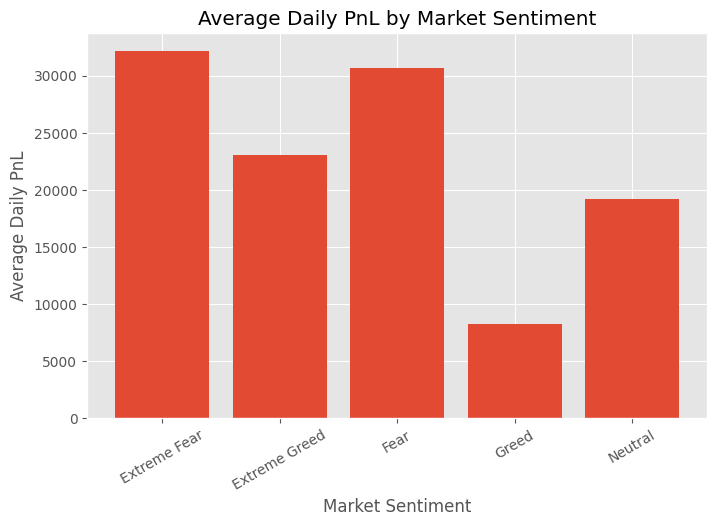

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(sentiment_analysis['classification'],
        sentiment_analysis['Avg_PnL'])

plt.title("Average Daily PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=30)

plt.show()

## Average Win Rate by Market Sentiment

The chart below compares the average proportion of profitable trades across different market sentiment categories. It helps evaluate whether traders achieve a higher success rate under specific market conditions.

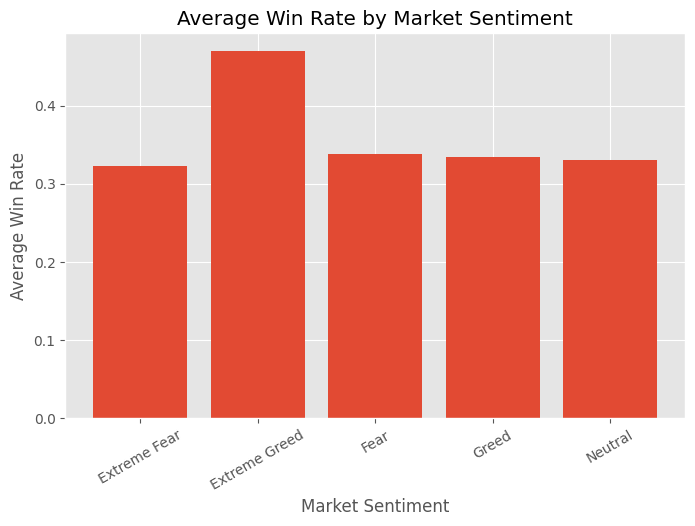

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(sentiment_analysis['classification'],
        sentiment_analysis['Avg_Win_Rate'])

plt.title("Average Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Win Rate")
plt.xticks(rotation=30)

plt.show()

## Average Trading Activity by Market Sentiment

This chart illustrates the average number of trades executed during each market sentiment category. It provides insight into how market sentiment influences trading activity.

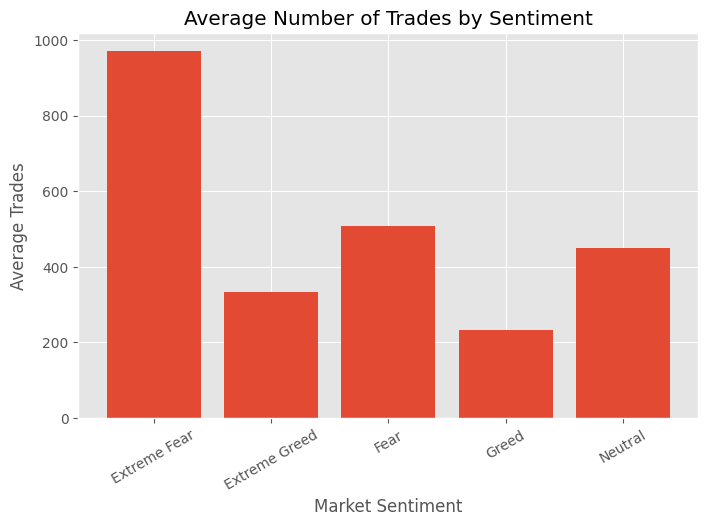

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(sentiment_analysis['classification'],
        sentiment_analysis['Avg_Trades'])

plt.title("Average Number of Trades by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trades")
plt.xticks(rotation=30)

plt.show()

## Average Trade Size by Market Sentiment

The following chart compares the average trade size (USD) across different market sentiment categories. It helps determine whether traders commit larger amounts of capital under particular market conditions.

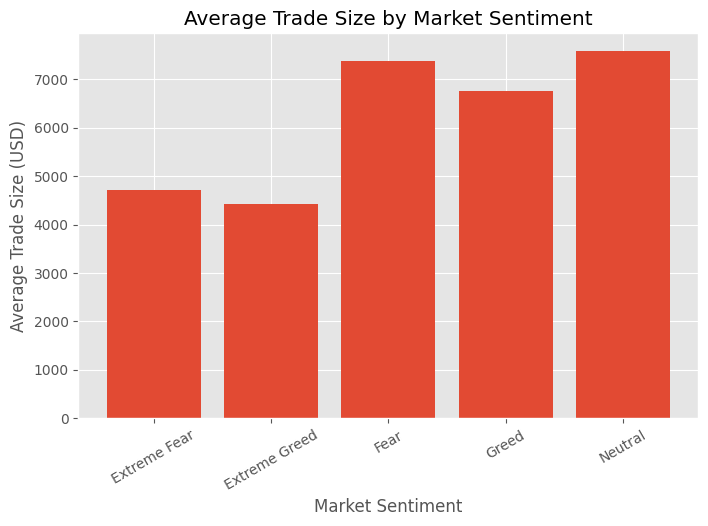

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(sentiment_analysis['classification'],
        sentiment_analysis['Avg_Trade_Size'])

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=30)

plt.show()

## Correlation Analysis

The correlation heatmap displays the relationships between numerical variables in the dataset. Correlation coefficients range from -1 to 1, where values closer to 1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate little or no linear relationship.

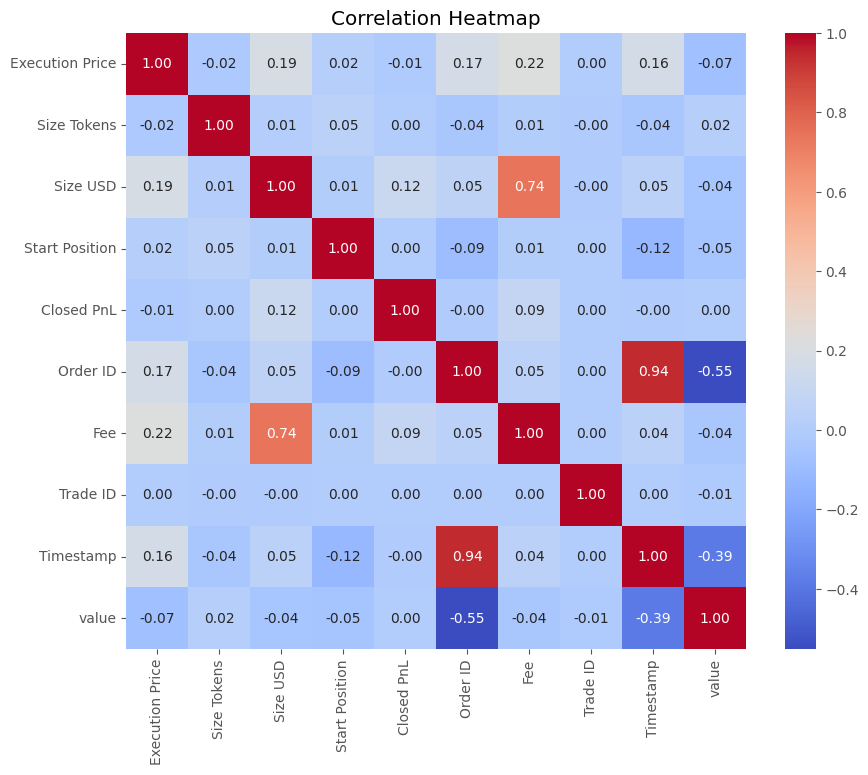

In [ ]:
import seaborn as sns

numeric_cols = merged.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Distribution of Profit and Loss Across Market Sentiments

This boxplot illustrates the distribution of individual trade profits and losses under different market sentiment categories. It highlights the spread of values, median performance, and the presence of outliers.

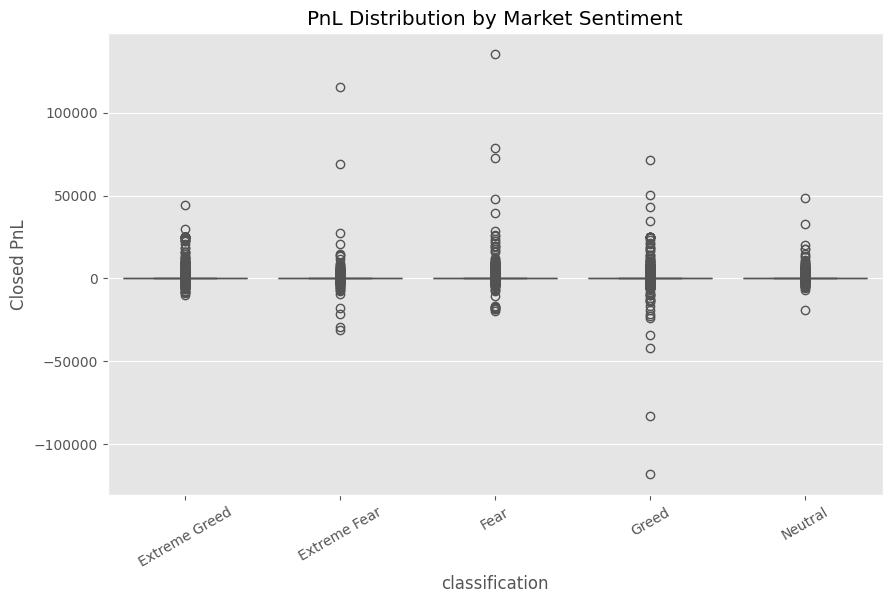

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution by Market Sentiment")
plt.xticks(rotation=30)

plt.show()

In [ ]:
trader_summary = (
    merged.groupby('Account')
    .agg(
        Total_PnL=('Closed PnL', 'sum'),
        Total_Trades=('Closed PnL', 'count'),
        Avg_Trade_Size=('Size USD', 'mean'),
        Win_Rate=('Win', 'mean')
    )
    .reset_index()
)

trader_summary.head()

,Account,Total_PnL,Total_Trades,Avg_Trade_Size,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,16159.576734,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,1653.226327,0.442720
2,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,507.626933,0.438585
3,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3239,3138.894782,0.519914
4,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-3.120360e+04,815,1729.941104,0.455215


In [ ]:
trader_summary.describe()

,Total_PnL,Total_Trades,Avg_Trade_Size,Win_Rate
count,2.700000e+01,27.000000,27.000000,27.000000
mean,3.253703e+05,6393.444444,5778.341386,0.415317
std,5.238259e+05,6274.827992,7869.902525,0.112312
min,-1.676211e+05,332.000000,507.626933,0.234987
25%,4.590116e+04,1106.000000,1898.315156,0.341460
50%,1.063029e+05,3818.000000,2979.441776,0.408526
75%,3.910535e+05,11064.500000,4989.971307,0.461398
max,2.143383e+06,21192.000000,34396.580284,0.810876


In [ ]:
median_trades = trader_summary['Total_Trades'].median()

trader_summary['Trader_Type'] = trader_summary['Total_Trades'].apply(
    lambda x: 'Frequent' if x >= median_trades else 'Infrequent'
)

In [ ]:
trader_summary['Trader_Type'].value_counts()

,count
Trader_Type,
Frequent,14
Infrequent,13


In [ ]:
trader_summary.groupby('Trader_Type').agg(
    Average_PnL=('Total_PnL','mean'),
    Average_Win_Rate=('Win_Rate','mean'),
    Average_Trade_Size=('Avg_Trade_Size','mean')
)

,Average_PnL,Average_Win_Rate,Average_Trade_Size
Trader_Type,,,
Frequent,514923.924950,0.420812,7788.468266
Infrequent,121235.599546,0.409399,3613.589361


## Average Profit by Trader Type

Traders were categorized as Frequent or Infrequent based on their trading activity. This visualization compares the average total profit generated by each group to understand how trading frequency relates to profitability.

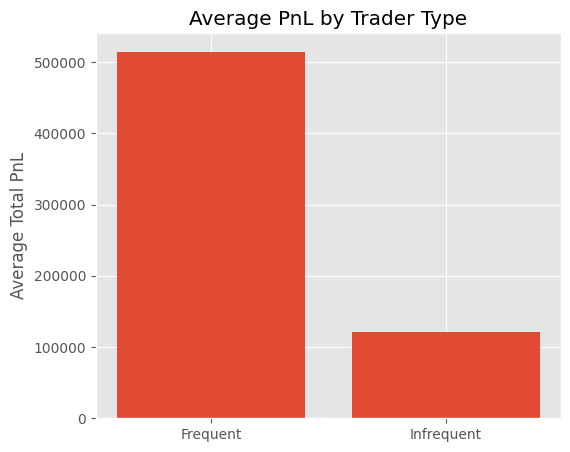

In [ ]:
comparison = trader_summary.groupby('Trader_Type')['Total_PnL'].mean()

plt.figure(figsize=(6,5))

plt.bar(comparison.index, comparison.values)

plt.title("Average PnL by Trader Type")
plt.ylabel("Average Total PnL")

plt.show()

In [ ]:
median_pnl = trader_summary['Total_PnL'].median()

trader_summary['Profit_Group'] = trader_summary['Total_PnL'].apply(
    lambda x: 'High Profit' if x >= median_pnl else 'Low Profit'
)

In [ ]:
trader_summary.groupby('Profit_Group').agg(
    Avg_Trades=('Total_Trades','mean'),
    Avg_Win_Rate=('Win_Rate','mean'),
    Avg_Size=('Avg_Trade_Size','mean')
)

,Avg_Trades,Avg_Win_Rate,Avg_Size
Profit_Group,,,
High Profit,8761.928571,0.427794,6781.757877
Low Profit,3842.769231,0.401880,4697.739010


In [ ]:
median_win = trader_summary['Win_Rate'].median()

trader_summary['Win_Group'] = trader_summary['Win_Rate'].apply(
    lambda x: 'High Win Rate' if x >= median_win else 'Low Win Rate'
)

In [ ]:
trader_summary.groupby('Win_Group').agg(
    Avg_PnL=('Total_PnL','mean'),
    Avg_Trades=('Total_Trades','mean'),
    Avg_Size=('Avg_Trade_Size','mean')
)

,Avg_PnL,Avg_Trades,Avg_Size
Win_Group,,,
High Win Rate,221556.994236,5905.857143,3784.597169
Low Win Rate,437169.217238,6918.538462,7925.450542


## Comparison of High-Profit and Low-Profit Traders

This chart compares the average total profit between traders classified as High Profit and Low Profit based on their overall profitability. It provides a clear comparison of trader performance across these groups.

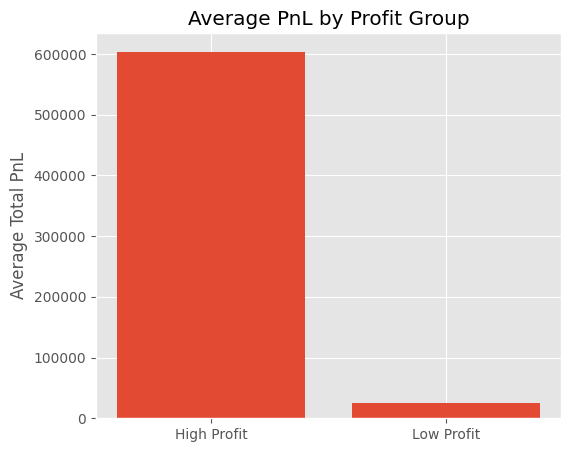

In [ ]:
profit_chart = trader_summary.groupby('Profit_Group')['Total_PnL'].mean()

plt.figure(figsize=(6,5))

plt.bar(profit_chart.index, profit_chart.values)

plt.title("Average PnL by Profit Group")
plt.ylabel("Average Total PnL")

plt.show()

## Comparison of Win Rate by Trader Group

Traders were segmented into High Win Rate and Low Win Rate groups based on their historical performance. This chart compares the average win rate of each group to evaluate trading consistency.

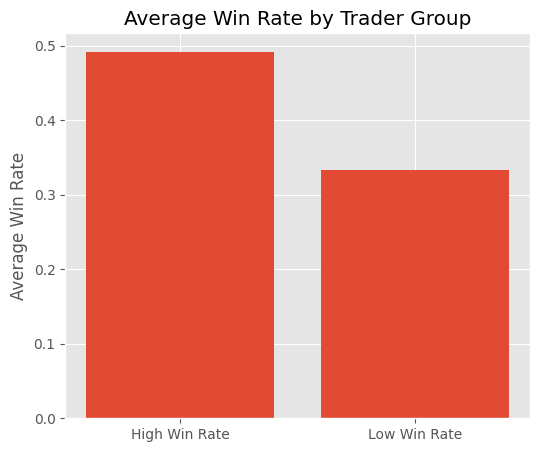

In [ ]:
win_chart = trader_summary.groupby('Win_Group')['Win_Rate'].mean()

plt.figure(figsize=(6,5))

plt.bar(win_chart.index, win_chart.values)

plt.title("Average Win Rate by Trader Group")
plt.ylabel("Average Win Rate")

plt.show()

## Discussion

### Performance Differences

Average profitability differed across market sentiment categories. Traders achieved the highest average daily PnL during Extreme Fear, while Extreme Greed produced the highest average win rate.

### Behavioral Differences

Trading frequency and average position size varied across market sentiments. Traders were generally more active during Fear-based market conditions.

### Limitations

Leverage analysis and drawdown analysis could not be performed because the dataset did not contain leverage information or portfolio equity required to compute drawdowns.

### **Methodology**

The analysis was conducted using two datasets: historical cryptocurrency trading records and the Bitcoin Fear & Greed Index. After cleaning and preprocessing the data, timestamps were converted to daily dates and both datasets were merged based on the trading date.

Key performance metrics such as daily profit and loss (PnL), win rate, average trade size, number of trades and Long/Short Ratio were calculated. Exploratory Data Analysis (EDA) and visualizations were used to compare trading performance across different market sentiment categories.

Finally, traders were segmented based on trading frequency, profitability and win rate to identify behavioral differences.

##**Insights**

##Insight 1

###Market Sentiment vs Profitability

Average daily PnL was highest during Extreme Fear and Fear periods, while Greed showed the lowest average daily PnL. This indicates that traders collectively achieved better profitability during bearish market conditions in the available dataset.

##Insight 2

###Market Sentiment vs Trading Activity

Trading activity increased significantly during Extreme Fear, where traders executed the highest average number of trades. This suggests that higher market uncertainty encourages more active trading.

##Insight 3

###Market Sentiment vs Win Rate

Although Extreme Fear generated the highest average daily profits, Extreme Greed produced the highest average win rate. This indicates that a higher proportion of winning trades does not necessarily translate into the highest overall profitability.

##Insight 4

###Trade Size

The largest average trade sizes occurred during Neutral and Fear market conditions, indicating that traders tended to commit larger amounts of capital when market sentiment was less optimistic.

##Insight 5

###PnL Distribution

The boxplot shows substantial variability in profit and loss across all market sentiment categories. Every sentiment contains both large gains and large losses, suggesting that market sentiment alone cannot fully explain trading performance.

##**Actionable Trading Strategies**

##Strategy 1: Increase Selective Trading During Fear Markets

###Rule of Thumb:

During Fear and Extreme Fear market conditions, traders may consider increasing trading activity while maintaining disciplined risk management, as these periods showed higher average daily profitability in the historical data.

###Reasoning:

Higher average PnL was observed during Fear-based market sentiment.
Traders were also more active during these periods.

##Strategy 2: Be More Selective During Greed Markets

###Rule of Thumb:

During Greed and Extreme Greed conditions, prioritize high-quality trade setups rather than increasing trade volume, since these periods showed higher win rates but not the highest overall profitability.

###Reasoning:

Extreme Greed had the highest average win rate.
However, average daily PnL was lower than during Fear periods, suggesting that a high win rate alone did not maximize profits.

##Strategy 3: Focus on Consistency Over Frequency

###Rule of Thumb:

Traders should emphasize consistent execution and risk management rather than simply increasing the number of trades, as higher trading frequency did not always guarantee the best performance.

###Reasoning:

Profitability varied widely across sentiment categories.
High-performing traders combined good win rates with disciplined trading rather than relying solely on more trades.

##**Trader Segmentation**

##Frequent Traders

Frequent traders generated substantially higher average total PnL than infrequent traders, indicating that greater trading participation was associated with higher cumulative profits in this dataset.

##High Profit Traders

Traders classified in the High Profit group significantly outperformed the Low Profit group in terms of total profitability.

##High Win Rate Traders

Traders with higher win rates maintained noticeably better average win percentages, demonstrating that consistent trade execution contributes to improved trading performance.

##**Recommendations**

##Recommendation 1

Traders should carefully monitor market sentiment before entering positions. Historical analysis suggests that Fear and Extreme Fear periods were associated with higher average profitability.

##Recommendation 2

Instead of maximizing the number of winning trades, traders should focus on risk management and position sizing, since the highest win rate did not correspond to the highest overall profits.

##Recommendation 3

High-performing traders should prioritize disciplined trade execution and consistent strategies rather than increasing trade frequency alone, as profit distribution remains highly variable across all sentiment categories.